In [1]:
import pickle
import numpy as np

def normalize_per_signal(x):
    min_v = x.min(axis=1, keepdims=True)
    max_v = x.max(axis=1, keepdims=True)

    return 2 * (x - min_v) / (max_v - min_v + 1e-8) - 1

NSR_PATH = "Dataset/NSR__procesado.pkl"

with open(NSR_PATH, "rb") as f:
    data_A= pickle.load(f)


signals = np.array(data_A['data'])   # (N_A, 1000)
#signals_B = np.array(data_B['data']["PVC"])   # (N_B, 1000)



In [2]:
!pip install fastdtw

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-py3-none-any.whl size=3612 sha256=f67292e101c6f31c9d45479ce066aad8d3cbf17acabdadf40e378f16e878d5d6
  Stored in directory: /tmp/pip-ephem-wheel-cache-7d36u46b/wheels/5c/8a/f6/fd3df9a9714677410a5ccbf3ca519e66db4a54a1c46ea95332
Successfully built fastdtw


In [6]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

def calculate_dtw_score(real_signals, fake_signals):
    # Tomamos una muestra para no tardar una eternidad
    # real_signals: (batch, 1, 3600)
    dtw_distances = []
    num_samples = min(len(real_signals), 10) # Comparamos 10 señales aleatorias
    
    for i in range(num_samples):
        # Convertimos a 1D
        r = real_signals[i].cpu().squeeze().numpy()
        f = fake_signals[i].cpu().squeeze().numpy()
        
        distance, _ = fastdtw(r, f, dist=euclidean)
        dtw_distances.append(distance)
    
    return np.mean(dtw_distances)

In [8]:
def calculate_dtw_score(real_signals, fake_signals):
    dtw_distances = []
    num_samples = min(len(real_signals), 8) 
    
    # Definimos una distancia simple: el valor absoluto de la diferencia entre dos puntos
    # Esto evita que scipy se queje por dimensiones
    simple_distance = lambda x, y: np.abs(x - y)

    for i in range(num_samples):
        # Aseguramos que sean arrays de numpy planos
        r = real_signals[i].detach().cpu().numpy().flatten()
        f = fake_signals[i].detach().cpu().numpy().flatten()
        
        # Usamos fastdtw con nuestra función simple
        distance, _ = fastdtw(r, f, dist=simple_distance)
        dtw_distances.append(distance)
        
    return np.mean(dtw_distances)


    # esta es la real vrd

In [3]:
def save_checkpoint(epoch, g_model, d_model, g_opt, d_opt, dtw_score, filename):
    checkpoint = {
        'epoch': epoch,
        'generator_state_dict': g_model.state_dict(),
        'discriminator_state_dict': d_model.state_dict(),
        'optimizer_g_state_dict': g_opt.state_dict(),
        'optimizer_d_state_dict': d_opt.state_dict(),
        'dtw_score': dtw_score
    }
    torch.save(checkpoint, filename)
    print(f"--- Checkpoint guardado: {filename} (DTW: {dtw_score:.4f}) ---")

Epoch [100/2000] | D Loss: 1.1566 | G Loss: 0.9084
Época 100 - DTW Score: 469.5960
--- Checkpoint guardado: best_model_dtw.pth (DTW: 469.5960) ---
¡Nuevo mejor modelo guardado! (DTW: 469.5960)


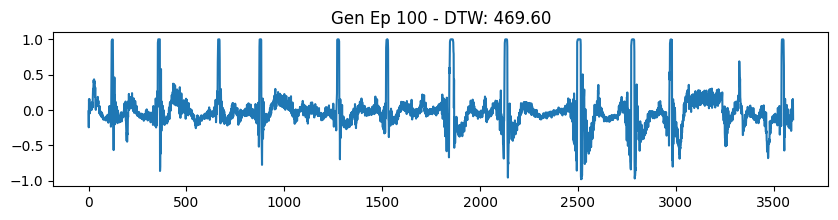

Epoch [200/2000] | D Loss: 0.8931 | G Loss: 2.0063
Época 200 - DTW Score: 396.8916
--- Checkpoint guardado: best_model_dtw.pth (DTW: 396.8916) ---
¡Nuevo mejor modelo guardado! (DTW: 396.8916)


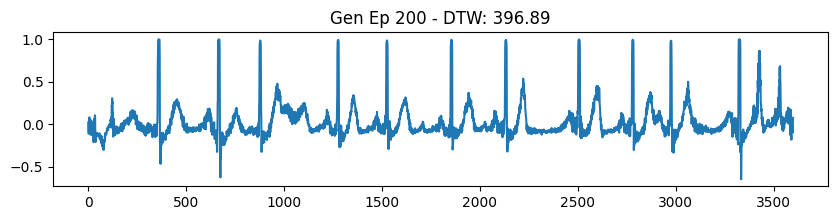

Epoch [300/2000] | D Loss: 1.0214 | G Loss: 1.0652
Época 300 - DTW Score: 406.6385


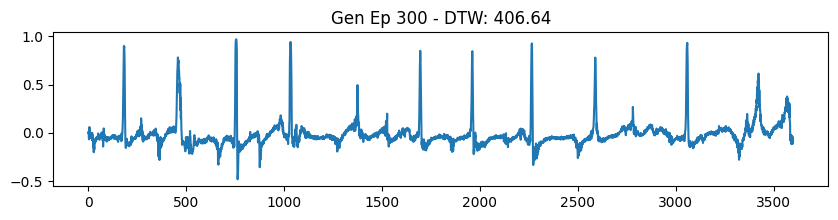

Epoch [400/2000] | D Loss: 1.1382 | G Loss: 1.0545
Época 400 - DTW Score: 390.9427
--- Checkpoint guardado: best_model_dtw.pth (DTW: 390.9427) ---
¡Nuevo mejor modelo guardado! (DTW: 390.9427)


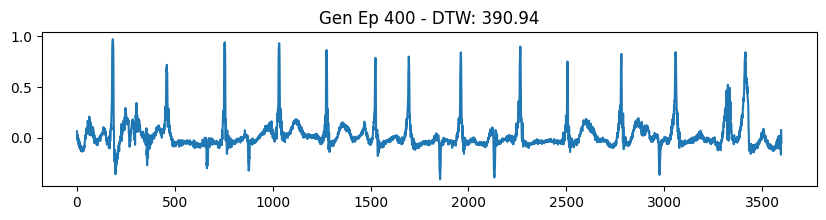

Epoch [500/2000] | D Loss: 0.6668 | G Loss: 2.2000
Época 500 - DTW Score: 390.1854
--- Checkpoint guardado: best_model_dtw.pth (DTW: 390.1854) ---
¡Nuevo mejor modelo guardado! (DTW: 390.1854)


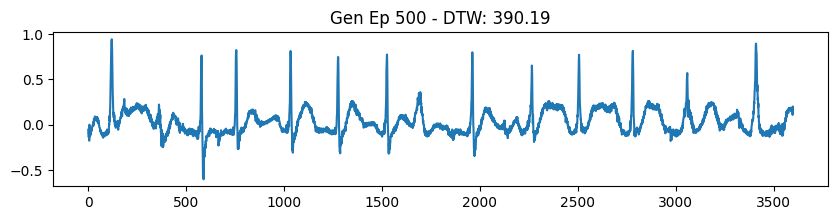

--- Checkpoint guardado: checkpoint_epoch_500.pth (DTW: 390.1854) ---
Epoch [600/2000] | D Loss: 0.6990 | G Loss: 2.0112
Época 600 - DTW Score: 368.8862
--- Checkpoint guardado: best_model_dtw.pth (DTW: 368.8862) ---
¡Nuevo mejor modelo guardado! (DTW: 368.8862)


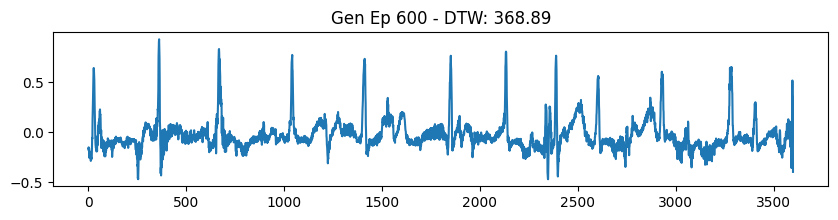

Epoch [700/2000] | D Loss: 0.8211 | G Loss: 1.7575
Época 700 - DTW Score: 302.5055
--- Checkpoint guardado: best_model_dtw.pth (DTW: 302.5055) ---
¡Nuevo mejor modelo guardado! (DTW: 302.5055)


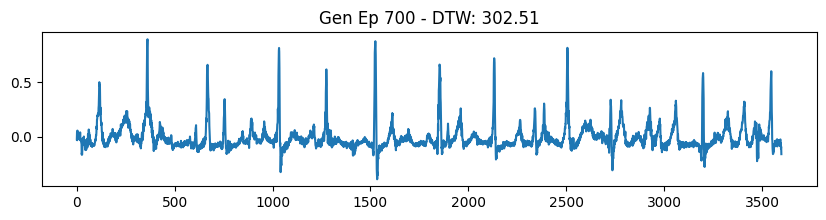

Epoch [800/2000] | D Loss: 0.6537 | G Loss: 2.4061
Época 800 - DTW Score: 359.5300


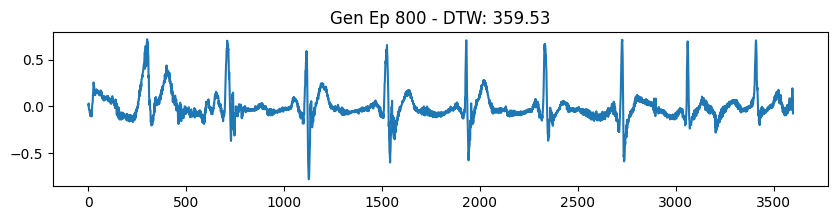

Epoch [900/2000] | D Loss: 0.6531 | G Loss: 2.2876
Época 900 - DTW Score: 492.2683


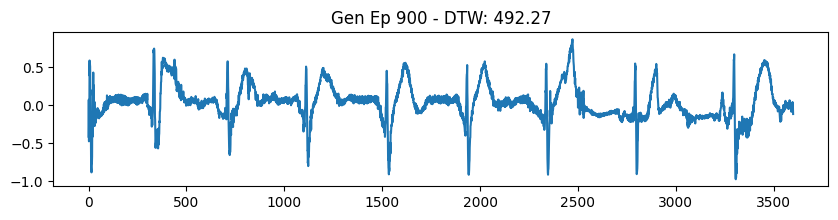

Epoch [1000/2000] | D Loss: 0.6540 | G Loss: 2.3230
Época 1000 - DTW Score: 423.6811


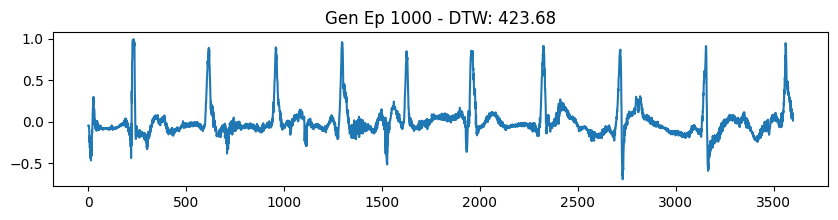

--- Checkpoint guardado: checkpoint_epoch_1000.pth (DTW: 423.6811) ---
Epoch [1100/2000] | D Loss: 0.7256 | G Loss: 1.9773
Época 1100 - DTW Score: 515.9250


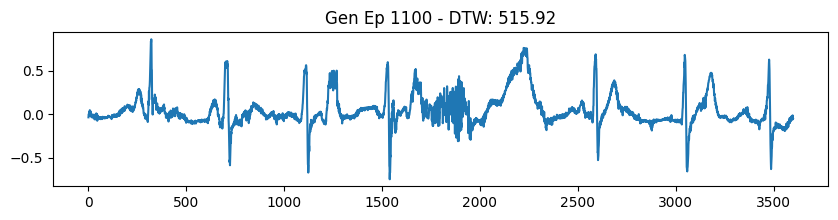

Epoch [1200/2000] | D Loss: 0.6547 | G Loss: 2.2282
Época 1200 - DTW Score: 316.7507


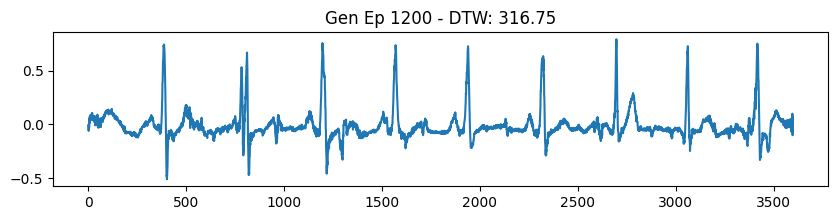

Epoch [1300/2000] | D Loss: 0.6558 | G Loss: 2.3556
Época 1300 - DTW Score: 346.4480


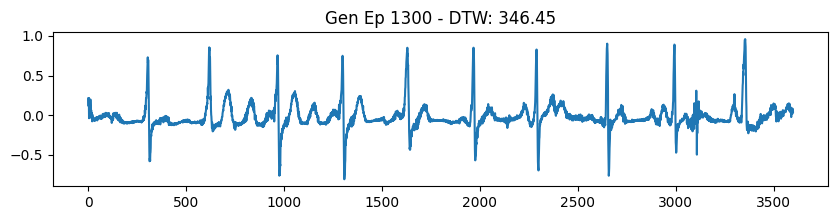

Epoch [1400/2000] | D Loss: 0.6682 | G Loss: 1.8853
Época 1400 - DTW Score: 443.6229


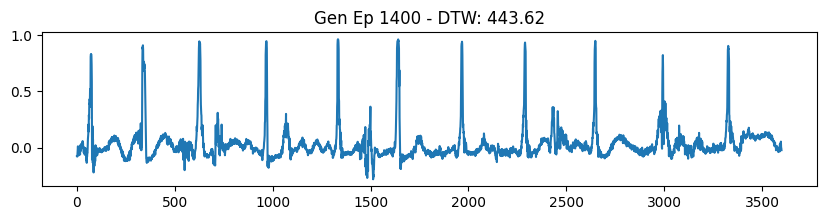

Epoch [1500/2000] | D Loss: 0.6517 | G Loss: 2.3379
Época 1500 - DTW Score: 398.2807


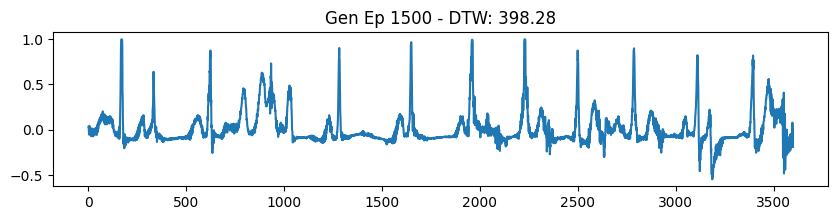

--- Checkpoint guardado: checkpoint_epoch_1500.pth (DTW: 398.2807) ---
Epoch [1600/2000] | D Loss: 0.6517 | G Loss: 2.2749
Época 1600 - DTW Score: 475.5094


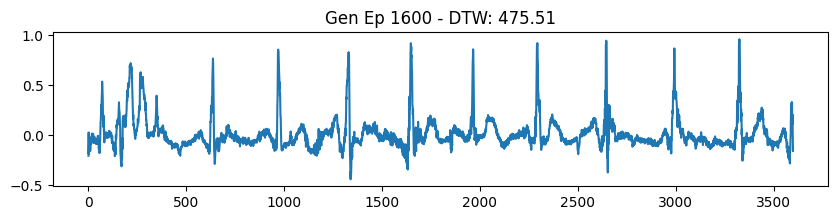

Epoch [1700/2000] | D Loss: 0.6518 | G Loss: 2.2579
Época 1700 - DTW Score: 371.7061


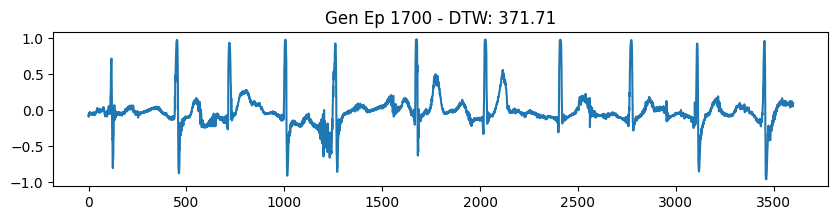

Epoch [1800/2000] | D Loss: 0.6510 | G Loss: 2.2783
Época 1800 - DTW Score: 365.2501


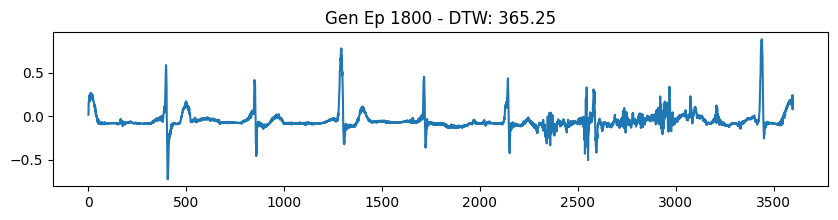

Epoch [1900/2000] | D Loss: 0.6510 | G Loss: 2.2607
Época 1900 - DTW Score: 464.2479


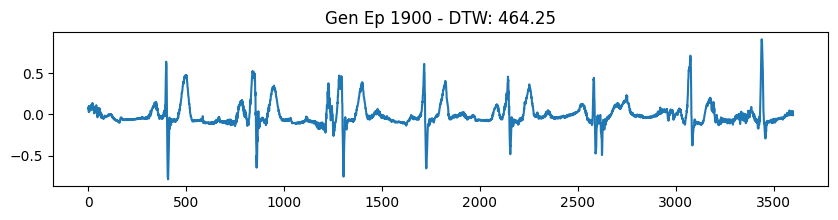

Epoch [2000/2000] | D Loss: 0.6612 | G Loss: 2.5691
Época 2000 - DTW Score: 392.6268


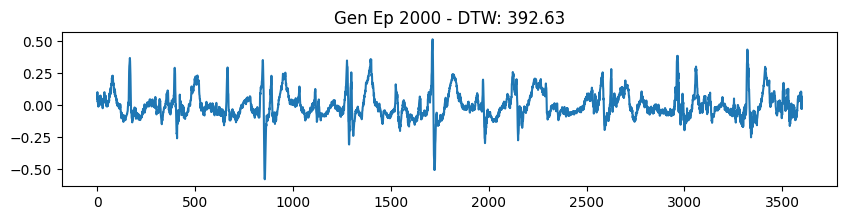

--- Checkpoint guardado: checkpoint_epoch_2000.pth (DTW: 392.6268) ---


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
signal_length = 3600
batch_size = 16
lr = 0.0001 # Un LR bajo ayuda a que la LSTM no explote
best_dtw = float('inf')  # Queremos la distancia mínima
num_epochs = 2000


# --- DATASET ---
class ECGDataset(Dataset):
    def __init__(self, signals):
        # Asumimos que ya vienen normalizados entre [-1, 1]
        self.signals = torch.tensor(signals, dtype=torch.float32)
        if self.signals.ndim == 2:
            self.signals = self.signals.unsqueeze(1)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        return self.signals[idx]

# --- MODELO: GENERADOR (FC4/FC5 + RESIDUAL) ---
class Generator(nn.Module):
    def __init__(self, latent_dim=100, signal_length=3600):
        super(Generator, self).__init__()
        self.signal_length = signal_length
        
        self.fc1 = nn.Linear(latent_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, 1024)
        self.bn3 = nn.BatchNorm1d(1024)
        
        self.lstm1 = nn.LSTM(1024, 512, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.lstm2 = nn.LSTM(1024, 256, num_layers=1, batch_first=True, bidirectional=True)
        
        # Las capas que mencionaste para dibujar los 3600 puntos
        self.fc4 = nn.Linear(512, signal_length)
        self.fc5 = nn.Linear(signal_length, signal_length)
        
    def forward(self, z):
        x = F.leaky_relu(self.bn1(self.fc1(z)), 0.2)
        x = F.leaky_relu(self.bn2(self.fc2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.fc3(x)), 0.2)
        
        x = x.unsqueeze(1) # (batch, 1, 1024)
        x, _ = self.lstm1(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x, _ = self.lstm2(x)
        
        x = x.squeeze(1) # (batch, 512)
        
        # Bloque Residual Final
        x1 = self.fc4(x)
        x2 = self.fc5(F.leaky_relu(x1, 0.2))
        x_final = x1 + x2 # Conexión residual
        
        return torch.tanh(x_final).unsqueeze(1)

# --- MODELO: DISCRIMINADOR ---
class Discriminator(nn.Module):
    def __init__(self, signal_length=3600):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, 15, stride=2, padding=7)
        self.conv2 = nn.Conv1d(32, 64, 15, stride=2, padding=7)
        self.conv3 = nn.Conv1d(64, 128, 15, stride=2, padding=7)
        
        self.lstm = nn.LSTM(128, 256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = F.leaky_relu(self.conv3(x), 0.2)
        
        x = x.transpose(1, 2)
        x, _ = self.lstm(x)
        x = torch.mean(x, dim=1) # Pooling
        
        x = F.leaky_relu(self.fc1(x), 0.2)
        return torch.sigmoid(self.fc2(x))

# --- BLOQUE DE ENTRENAMIENTO ---



G = Generator(latent_dim, signal_length).to(device)
D = Discriminator(signal_length).to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

'''
scheduler_G = torch.optim.lr_scheduler.StepLR(opt_G, step_size=500, gamma=0.5)
scheduler_D = torch.optim.lr_scheduler.StepLR(opt_D, step_size=500, gamma=0.5)

# Al final de cada época:
scheduler_G.step()
scheduler_D.step()
'''
####

criterion = nn.BCELoss()

# Supón que ya tienes 'signals_norm' cargada
loader = DataLoader(ECGDataset(signals), batch_size=batch_size, shuffle=True)

for epoch in range(num_epochs):
    for i, real_signals in enumerate(loader):
        real_signals = real_signals.to(device)
        b_size = real_signals.size(0)
        
        # Labels con Smoothing
        real_labels = torch.full((b_size, 1), 0.9, device=device)
        fake_labels = torch.full((b_size, 1), 0.1, device=device)

        # 1. Entrenar Discriminador
        opt_D.zero_grad()
        out_real = D(real_signals)
        loss_real = criterion(out_real, real_labels)
        
        z = torch.randn(b_size, latent_dim, device=device)
        fake_signals = G(z)
        out_fake = D(fake_signals.detach())
        loss_fake = criterion(out_fake, fake_labels)
        
        d_loss = loss_real + loss_fake
        d_loss.backward()
        opt_D.step()

        # 2. Entrenar Generador
        opt_G.zero_grad()
        out_g = D(fake_signals)
        g_loss = criterion(out_g, torch.ones(b_size, 1, device=device))
        g_loss.backward()
        opt_G.step()



    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")
        G.eval()

        with torch.no_grad():
            z = torch.randn(batch_size, latent_dim, device=device)
            gen_samples = G(z)
            # Calculamos DTW comparando con el último batch de reales
            current_dtw = calculate_dtw_score(real_signals, gen_samples)

            print(f"Época {epoch+1} - DTW Score: {current_dtw:.4f}")

            # Si es el mejor modelo hasta ahora, lo guardamos
            if current_dtw < best_dtw:
                best_dtw = current_dtw
                save_checkpoint(epoch, G, D, opt_G, opt_D, current_dtw, 'best_model_dtw.pth')
                print(f"¡Nuevo mejor modelo guardado! (DTW: {best_dtw:.4f})")
                
           # Visualización rápida

            plt.figure(figsize=(10, 2))
            plt.plot(gen_samples[0].cpu().squeeze().numpy())
            plt.title(f"Gen Ep {epoch+1} - DTW: {current_dtw:.2f}")
            plt.show()

            if (epoch + 1) % 500 == 0:
                save_checkpoint(epoch, G, D, opt_G, opt_D, current_dtw, f'checkpoint_epoch_{epoch+1}.pth')
        G.train()
    
